In [281]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = '#00000000'

In [ ]:
df = pd.read_csv('../data/data.csv')
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [283]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [284]:
df.select_dtypes(np.number).corr()['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.430410
sqft_above       0.367570
bathrooms        0.327110
view             0.228504
sqft_basement    0.210427
bedrooms         0.200336
floors           0.151461
waterfront       0.135648
sqft_lot         0.050451
condition        0.034915
yr_built         0.021857
yr_renovated    -0.028774
Name: price, dtype: float64

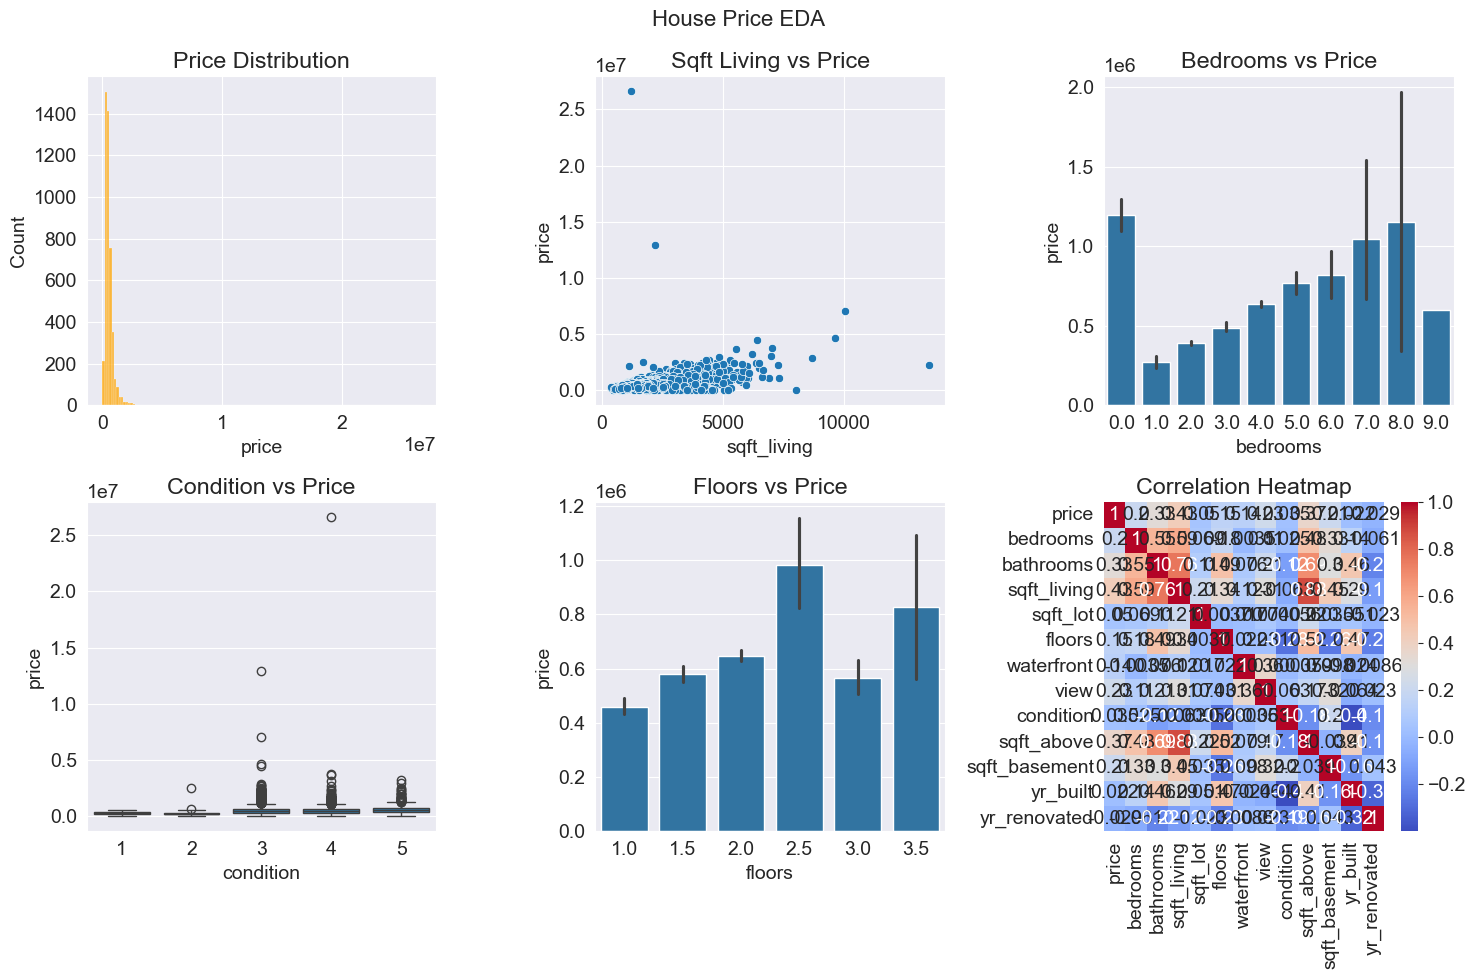

In [285]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
fig.suptitle('House Price EDA', fontsize = 16)

sns.histplot(df, x = 'price', ax = axes[0, 0], color = 'orange')
axes[0, 0].set_title('Price Distribution')

sns.scatterplot(df, x = 'sqft_living', y = 'price', ax = axes[0, 1])
axes[0, 1].set_title('Sqft Living vs Price')

sns.barplot(df, x = 'bedrooms', y = 'price', ax = axes[0, 2])
axes[0, 2].set_title('Bedrooms vs Price')

sns.boxplot(df, x = 'condition', y = 'price', ax = axes[1, 0])
axes[1, 0].set_title('Condition vs Price')

sns.barplot(df, x = 'floors', y = 'price', ax = axes[1, 1])
axes[1, 1].set_title('Floors vs Price')

sns.heatmap(df.select_dtypes(np.number).corr(), annot = True, cmap = 'coolwarm', ax = axes[1, 2])
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [286]:
input_cols = df.select_dtypes(np.number).columns.drop('price').tolist()

target_col = 'price'

df = df[df['price'] > 0]

In [287]:
df[input_cols].nunique()

bedrooms           10
bathrooms          26
sqft_living       561
sqft_lot         3087
floors              6
waterfront          2
view                5
condition           5
sqft_above        510
sqft_basement     207
yr_built          115
yr_renovated       59
dtype: int64

In [288]:
from sklearn.model_selection import train_test_split

In [289]:
train_df, test_df = train_test_split(df, test_size = 0.2, random_state = 42)

train_df, val_df = train_test_split(train_df, test_size = 0.2, random_state = 42)

print(f"Train size: {len(train_df)}")
print(f"Val size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 2912
Val size: 728
Test size: 911


In [290]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

test_inputs = test_df[input_cols].copy()
test_targets = test_df[target_col].copy()

In [291]:
val_inputs

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
2646,3.0,2.00,1730,9000,1.0,0,0,3,1370,360,1978,0
137,4.0,1.75,2010,9211,1.0,0,0,3,1470,540,1977,2004
583,4.0,1.50,1950,12559,1.5,0,0,3,1950,0,1939,1969
299,3.0,1.50,1380,11130,1.0,0,0,3,1380,0,1960,2012
2405,4.0,2.50,2470,35073,2.0,0,0,3,2470,0,1989,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4543,3.0,2.50,1150,887,3.0,0,0,3,1150,0,2007,0
442,4.0,2.75,3780,10308,2.0,0,0,3,3780,0,1999,0
1310,4.0,3.50,2630,3435,1.5,0,3,3,1640,990,1984,0
894,4.0,2.00,1580,7800,2.0,0,0,2,1580,0,1906,0


In [292]:
from sklearn.impute import SimpleImputer

In [293]:
numeric_cols = train_inputs.select_dtypes(np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object', 'str').columns.tolist()

In [294]:
train_inputs.dtypes

bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
dtype: object

NO CATEGORICAL COLUMNS IN THIS DATASET

In [295]:
imputer = SimpleImputer(strategy = 'mean').fit(train_inputs[numeric_cols])

In [296]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [297]:
val_inputs[numeric_cols]

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
2646,3.0,2.00,1730.0,9000.0,1.0,0.0,0.0,3.0,1370.0,360.0,1978.0,0.0
137,4.0,1.75,2010.0,9211.0,1.0,0.0,0.0,3.0,1470.0,540.0,1977.0,2004.0
583,4.0,1.50,1950.0,12559.0,1.5,0.0,0.0,3.0,1950.0,0.0,1939.0,1969.0
299,3.0,1.50,1380.0,11130.0,1.0,0.0,0.0,3.0,1380.0,0.0,1960.0,2012.0
2405,4.0,2.50,2470.0,35073.0,2.0,0.0,0.0,3.0,2470.0,0.0,1989.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4543,3.0,2.50,1150.0,887.0,3.0,0.0,0.0,3.0,1150.0,0.0,2007.0,0.0
442,4.0,2.75,3780.0,10308.0,2.0,0.0,0.0,3.0,3780.0,0.0,1999.0,0.0
1310,4.0,3.50,2630.0,3435.0,1.5,0.0,3.0,3.0,1640.0,990.0,1984.0,0.0
894,4.0,2.00,1580.0,7800.0,2.0,0.0,0.0,2.0,1580.0,0.0,1906.0,0.0


In [298]:
from sklearn.preprocessing import MinMaxScaler

In [299]:
scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

In [300]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [301]:
val_inputs[numeric_cols]

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
2646,0.333333,0.307692,0.191241,0.012952,0.0,0.0,0.00,0.50,0.158070,0.126316,0.684211,0.000000
137,0.444444,0.269231,0.232117,0.013282,0.0,0.0,0.00,0.50,0.174709,0.189474,0.675439,0.995035
583,0.444444,0.230769,0.223358,0.018509,0.2,0.0,0.00,0.50,0.254576,0.000000,0.342105,0.977656
299,0.333333,0.230769,0.140146,0.016278,0.0,0.0,0.00,0.50,0.159734,0.000000,0.526316,0.999007
2405,0.444444,0.384615,0.299270,0.053660,0.4,0.0,0.00,0.50,0.341098,0.000000,0.780702,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4543,0.333333,0.384615,0.106569,0.000286,0.8,0.0,0.00,0.50,0.121464,0.000000,0.938596,0.000000
442,0.444444,0.423077,0.490511,0.014995,0.4,0.0,0.00,0.50,0.559068,0.000000,0.868421,0.000000
1310,0.444444,0.538462,0.322628,0.004264,0.2,0.0,0.75,0.50,0.202995,0.347368,0.736842,0.000000
894,0.444444,0.307692,0.169343,0.011079,0.4,0.0,0.00,0.25,0.193012,0.000000,0.052632,0.000000


In [302]:
X_train = train_inputs[numeric_cols]
X_val = val_inputs[numeric_cols]
X_test = test_inputs[numeric_cols]

In [303]:
X_val

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
2646,0.333333,0.307692,0.191241,0.012952,0.0,0.0,0.00,0.50,0.158070,0.126316,0.684211,0.000000
137,0.444444,0.269231,0.232117,0.013282,0.0,0.0,0.00,0.50,0.174709,0.189474,0.675439,0.995035
583,0.444444,0.230769,0.223358,0.018509,0.2,0.0,0.00,0.50,0.254576,0.000000,0.342105,0.977656
299,0.333333,0.230769,0.140146,0.016278,0.0,0.0,0.00,0.50,0.159734,0.000000,0.526316,0.999007
2405,0.444444,0.384615,0.299270,0.053660,0.4,0.0,0.00,0.50,0.341098,0.000000,0.780702,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4543,0.333333,0.384615,0.106569,0.000286,0.8,0.0,0.00,0.50,0.121464,0.000000,0.938596,0.000000
442,0.444444,0.423077,0.490511,0.014995,0.4,0.0,0.00,0.50,0.559068,0.000000,0.868421,0.000000
1310,0.444444,0.538462,0.322628,0.004264,0.2,0.0,0.75,0.50,0.202995,0.347368,0.736842,0.000000
894,0.444444,0.307692,0.169343,0.011079,0.4,0.0,0.00,0.25,0.193012,0.000000,0.052632,0.000000


In [304]:
def baseline_model(inputs):
    return np.full(len(inputs.index), train_targets.mean())

In [305]:
from sklearn.metrics import mean_squared_error

In [306]:
train_preds = baseline_model(X_train)
train_preds

array([558589.76224558, 558589.76224558, 558589.76224558, ...,
       558589.76224558, 558589.76224558, 558589.76224558], shape=(2912,))

In [307]:
train_rmse = np.sqrt(mean_squared_error(train_preds, train_targets))
train_rmse

np.float64(634577.4134744249)

In [308]:
val_preds = baseline_model(X_val)
val_preds

array([558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 558589.76224558, 558589.76224558, 558589.76224558,
       558589.76224558, 5

In [309]:
val_rmse = np.sqrt(mean_squared_error(val_preds, val_targets))
val_rmse

np.float64(436671.2128507272)

In [310]:
from sklearn.linear_model import LinearRegression

In [311]:
model = LinearRegression().fit(X_train, train_targets)

In [312]:
train_preds = model.predict(X_train)
train_preds

array([104219.65910737, 359695.33153849, 570468.98830577, ...,
       320082.07831979, 634590.02125235, 764476.23139427], shape=(2912,))

In [313]:
val_preds = model.predict(X_val)
val_preds

array([ 403444.77362549,  399384.57532233,  491754.69798314,
        349357.40568716,  576101.79369856,  306061.88659284,
        544781.87397105,  471874.35239821,  448051.88227529,
        196926.93139639, 1081822.09992397,  677093.37846968,
        471004.25689456,  316252.45566826,  569262.01655835,
        319735.91689709,  534203.31654397,  806934.97219363,
        806001.24417269,  576036.13032622,  311594.57272134,
        661383.09664163,  726248.82081973,  562695.45593339,
        198407.44089649,  462110.53198109,  574115.25564375,
        693169.69029813,  296174.11939011,  320244.64663938,
        269674.17033474,  349483.0527792 ,  399109.79654337,
        495538.72328082,  536000.78357794, 1558899.78949913,
        725194.62146379,  484010.73612141,  649043.98943625,
        549555.35284887,  649641.88228016,  587129.24123629,
        369456.15877116,  508983.8756272 ,  120626.44974425,
        387491.38802688,  383306.43701825,  676754.33468126,
       1307720.97095849,

In [314]:
X_train.columns.tolist()

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated']

In [315]:
train_rmse = np.sqrt(mean_squared_error(train_preds, train_targets))
train_rmse

np.float64(584882.0439736797)

In [316]:
val_rmse = np.sqrt(mean_squared_error(val_preds, val_targets))
val_rmse

np.float64(281508.929070041)

In [317]:
from sklearn.ensemble import RandomForestRegressor

In [318]:
rf = RandomForestRegressor(random_state = 42, n_jobs = -1).fit(X_train, train_targets)

In [319]:
train_preds = rf.predict(X_train)
train_preds

array([144635.295     , 438393.5       , 423502.29428571, ...,
       437902.48333334, 467675.21333333, 612864.76818182], shape=(2912,))

In [320]:
val_preds = rf.predict(X_val)
val_preds

array([ 372435.25      ,  373023.17761904,  410834.3       ,
        328221.19230769,  624234.71      ,  292092.6       ,
        490562.07      ,  343320.79999994,  416997.08      ,
        280753.03      , 1166451.5       ,  605744.2857143 ,
        438427.42023808,  315591.40555556,  588417.67      ,
        263617.3       ,  592503.11130434,  899980.09      ,
        841451.65428571, 1998473.79261904,  375757.12      ,
        525897.21666668,  757985.2237069 ,  449916.23      ,
        356859.21      ,  409144.4       ,  626902.88999999,
        555298.22      ,  416546.79555556,  453154.81      ,
        355239.00476191,  480151.5       ,  308265.21142858,
        577909.55      ,  517600.        , 1956941.7233333 ,
        633055.06      ,  420473.65      ,  680327.93714286,
        442542.73      ,  585534.04      ,  580390.08666667,
        338410.75      ,  584466.5984472 ,  171870.75833333,
        330842.92555556,  304918.178     ,  625343.38      ,
       1409438.63      ,

In [321]:
train_rmse = np.sqrt(mean_squared_error(train_preds, train_targets))
train_rmse

np.float64(227252.46003578868)

In [322]:
val_rmse = np.sqrt(mean_squared_error(val_preds, val_targets))
val_rmse

np.float64(342207.86968857865)

In [323]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42, n_jobs = -1, max_depth = 15).fit(X_train, train_targets)

In [324]:
train_preds = rf.predict(X_train)
val_preds = rf.predict(X_val)

In [325]:
train_rmse = np.sqrt(mean_squared_error(train_preds, train_targets))
train_rmse

np.float64(232535.1533759941)

In [326]:
val_rmse = np.sqrt(mean_squared_error(val_preds, val_targets))
val_rmse

np.float64(330959.3151227229)

In [327]:
rf.feature_importances_

array([0.02833015, 0.05555214, 0.30395658, 0.10855187, 0.02235357,
       0.00281381, 0.0131208 , 0.10610515, 0.10497272, 0.03863663,
       0.17446393, 0.04114266])

In [328]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending = False)

In [329]:
importance_df

,feature,importance
2,sqft_living,0.303957
10,yr_built,0.174464
3,sqft_lot,0.108552
7,condition,0.106105
8,sqft_above,0.104973
1,bathrooms,0.055552
11,yr_renovated,0.041143
9,sqft_basement,0.038637
0,bedrooms,0.028330
4,floors,0.022354


<Axes: xlabel='importance', ylabel='feature'>

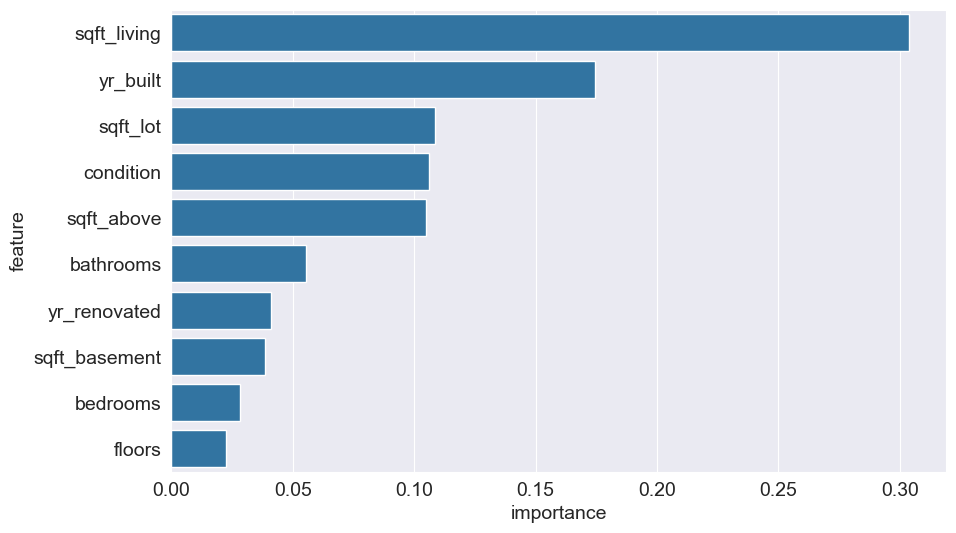

In [330]:
sns.barplot(importance_df.head(10), x = 'importance', y = 'feature')

In [331]:
test_preds = model.predict(X_test)
test_preds

array([1297482.46456296,  574525.28140312,  648890.45497078,
        302547.30263028,  518706.38799243,  537132.80227668,
        245989.68139407,  198110.79554144,  375957.82170387,
        679794.99175759,  466583.0775082 ,  277518.0570645 ,
        788990.82163316,  711800.39991593,  733093.78303284,
        540179.34325653,  347539.86585082,  736027.16375879,
        588780.31591826,  687265.2273992 ,  541438.80470772,
        261338.11507328, 1237422.4641862 ,  232137.67335876,
        663842.25880369,  830918.26861286,  773858.03001897,
        511365.49511603,  412228.96741549,  450122.10161691,
        388830.91111428,  629914.64666308,  615091.15911887,
        221701.77261055,  660846.6768993 ,  621216.8093463 ,
        504268.89055858,  545417.57260592,  573406.04843291,
        432178.8459906 ,  735120.97706887,  642859.63871018,
        563856.82343654,  301339.33766058,  705021.28081671,
        255340.04314845,  441624.63162864,  762804.01597587,
        452476.3456634 ,

In [332]:
test_rmse = np.sqrt(mean_squared_error(test_preds, test_targets))
test_rmse

np.float64(248834.02961520848)

In [335]:
print("=" * 50)
print("HOUSE PRICE PREDICTION — RESULTS")
print("=" * 50)
print(f"Baseline RMSE:              ${374525:.0f}")
print(f"Linear Regression Val RMSE: ${237512:.0f}")
print(f"Final Test RMSE:            ${248834:.0f}")
print(f"Best Feature:               sqft_living (0.52 importance)")
print("=" * 50)

HOUSE PRICE PREDICTION — RESULTS
Baseline RMSE:              $374525
Linear Regression Val RMSE: $237512
Final Test RMSE:            $248834
Best Feature:               sqft_living (0.52 importance)
